# 02 -- Preprocessing

This notebook demonstrates the preprocessing API implemented in `aquinas_toolkit.preprocessing`.

Why it looks the way it does:

- organizer guidance from April 2, 2026 and April 9, 2026 is summarized in `docs/README.md`
- code-level decisions and defaults are tracked in `aquinas_toolkit/preprocessing/README.md`
- event lookup, alignment, and zeroing ideas were adapted from `AQUINAS_Explorer.R`, shared on April 9, 2026

The notebook is intentionally a consumer of the package API. It does not define reusable preprocessing logic locally.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from aquinas_toolkit import AquinasReader
from aquinas_toolkit.preprocessing import (
    align_event_group,
    export_aligned_event,
    find_events,
    load_event_group,
    zero_loaded_event_group,
)


In [2]:
dataset_dir = Path("..") / "AQUINAS_DATASET" / "AQUINAS_SET1_2022_07"
reader = AquinasReader(dataset_dir)

shared_timestamps = [
    "2022-07-02 03:34:40",
    "2022-07-30 18:36:53",
]
shared_timestamps


['2022-07-02 03:34:40', '2022-07-30 18:36:53']

## Find organizer-shared examples

The original R script selected timestamp windows and then loaded every matching sensor record on the chosen deck. The Python API keeps that workflow, but groups events by exact metadata times first.


In [3]:
events_for_first_timestamp = find_events(
    reader,
    timestamp=shared_timestamps[0],
    deck="OLD",
    sensor_pattern="STR",
)
events_for_first_timestamp.head()


,event_id,set_name,deck,start_time_utc,end_time_utc,active_sensor_count,active_sensors
0,AQUINAS_SET1_2022_07__OLD__2022-07-02T03-34-37...,AQUINAS_SET1_2022_07,OLD,2022-07-02 03:34:37+00:00,2022-07-02 03:34:49+00:00,12,"[OLD_S1_DO_INF_STR, OLD_S1_DO_SHE_STR, OLD_S1_..."


In [4]:
selected_event = events_for_first_timestamp.iloc[0]
loaded_event = load_event_group(reader, selected_event)
aligned_event = align_event_group(loaded_event)

aligned_event.alignment_diagnostics


{'method': 'r_synchro',
 'reference_sensor': 'OLD_S1_DO_INF_STR',
 'reference_policy': 'first_selected',
 'passes': 2,
 'rows_reference': 1238,
 'rows_after_alignment': 1231,
 'match_stats': {'OLD_S1_DO_INF_STR': {'matched_rows': 1231,
   'unmatched_rows': 7},
  'OLD_S1_DO_SHE_STR': {'matched_rows': 1231, 'unmatched_rows': 6},
  'OLD_S1_DO_SUP_STR': {'matched_rows': 1231, 'unmatched_rows': 7},
  'OLD_S1_UP_INF_STR': {'matched_rows': 1231, 'unmatched_rows': 7},
  'OLD_S1_UP_SHE_STR': {'matched_rows': 1231, 'unmatched_rows': 6},
  'OLD_S1_UP_SUP_STR': {'matched_rows': 1231, 'unmatched_rows': 7},
  'OLD_S2_DO_INF_STR': {'matched_rows': 1231, 'unmatched_rows': 5},
  'OLD_S2_DO_SHE_STR': {'matched_rows': 1231, 'unmatched_rows': 6},
  'OLD_S2_DO_SUP_STR': {'matched_rows': 1231, 'unmatched_rows': 5},
  'OLD_S2_UP_INF_STR': {'matched_rows': 1231, 'unmatched_rows': 5},
  'OLD_S2_UP_SHE_STR': {'matched_rows': 1231, 'unmatched_rows': 6},
  'OLD_S2_UP_SUP_STR': {'matched_rows': 1231, 'unmatched_ro

## Organizer-style multi-sensor event view

The organizer material shows one event with many strain sensors overlaid on a shared time axis. The cell below mirrors that style for a real `SET2` event on the `OLD` deck recorded around `2023-04-20 07:04:05`. Alignment is applied first so the traces share one timestamp grid, but no zeroing is applied yet.


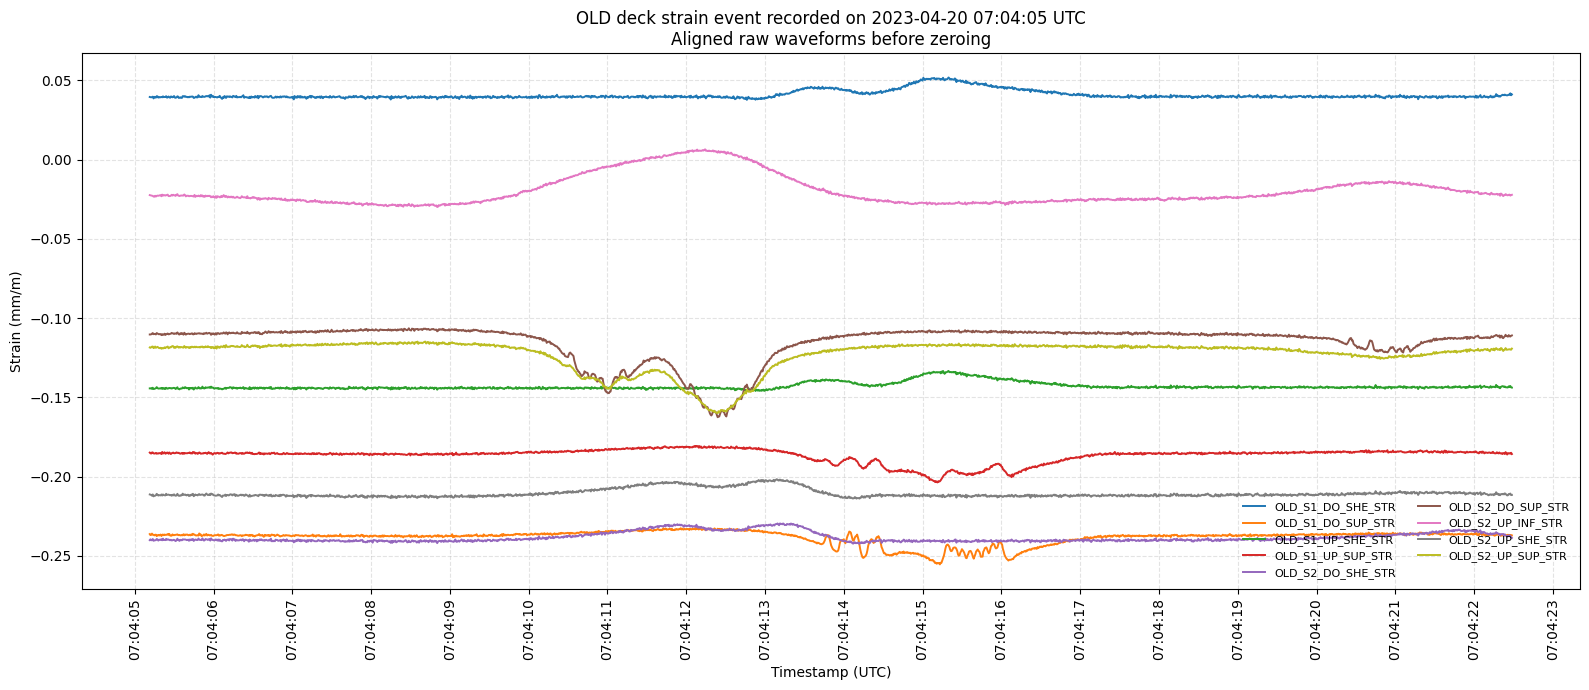

In [5]:
import matplotlib.dates as mdates

organizer_reader = AquinasReader(Path("..") / "AQUINAS_DATASET" / "AQUINAS_SET2_2023_04")
organizer_timestamp = "2023-04-20 07:04:10"

organizer_events = find_events(
    organizer_reader,
    timestamp=organizer_timestamp,
    deck="OLD",
    sensor_pattern="STR",
)
if organizer_events.empty:
    raise ValueError(f"No OLD-deck strain event found for {organizer_timestamp} in SET2.")

organizer_event = organizer_events.iloc[0]
organizer_loaded_event = load_event_group(organizer_reader, organizer_event)
organizer_aligned_event = align_event_group(organizer_loaded_event)
organizer_frame = organizer_aligned_event.aligned_waveform
organizer_sensor_columns = [
    column for column in organizer_frame.columns if column != "timestamp_utc"
]

fig, ax = plt.subplots(figsize=(16, 7))
for sensor_name in organizer_sensor_columns:
    ax.plot(
        organizer_frame["timestamp_utc"],
        organizer_frame[sensor_name],
        linewidth=1.4,
        label=sensor_name,
    )

ax.set_title(
    "OLD deck strain event recorded on 2023-04-20 07:04:05 UTC\n"
    "Aligned raw waveforms before zeroing"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Strain (mm/m)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()


## See the effect of default zeroing

The previous strain plot shows the organizer-style multi-sensor event before baseline correction. This cell replots the same event after applying the package default zeroing method.


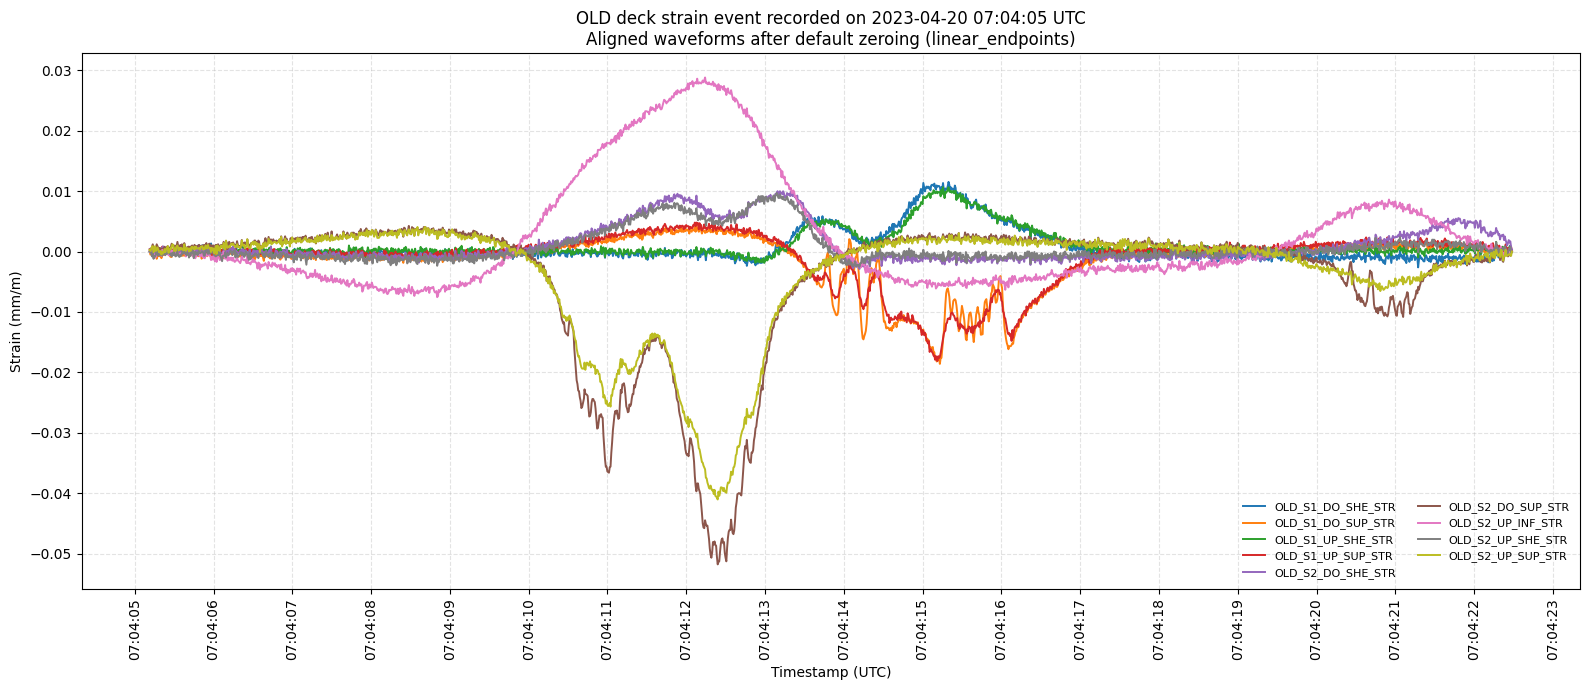

In [6]:
organizer_zeroed_loaded_event = zero_loaded_event_group(organizer_loaded_event)
organizer_zeroed_event = align_event_group(organizer_zeroed_loaded_event)
zeroed_frame = organizer_zeroed_event.aligned_waveform

fig, ax = plt.subplots(figsize=(16, 7))

for sensor_name in organizer_sensor_columns:
    ax.plot(
        zeroed_frame["timestamp_utc"],
        zeroed_frame[sensor_name],
        linewidth=1.4,
        label=sensor_name,
    )

ax.set_title(
    "OLD deck strain event recorded on 2023-04-20 07:04:05 UTC\n"
    f"Aligned waveforms after default zeroing ({organizer_zeroed_event.zeroing_method})"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Strain (mm/m)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()


## Organizer-style acceleration view

The organizer material also shows a multi-sensor Z-acceleration event on a shared time axis. The example is labeled `2022-09-01 17:51:55`, but that timestamp is not present in the released competition dataset in this repository. The next two cells therefore use a real upstream `ACC_Z` event from `SET1` on `2022-07-30 18:36:53`, which is an interior timestamp under the organizer's strict containment rule.


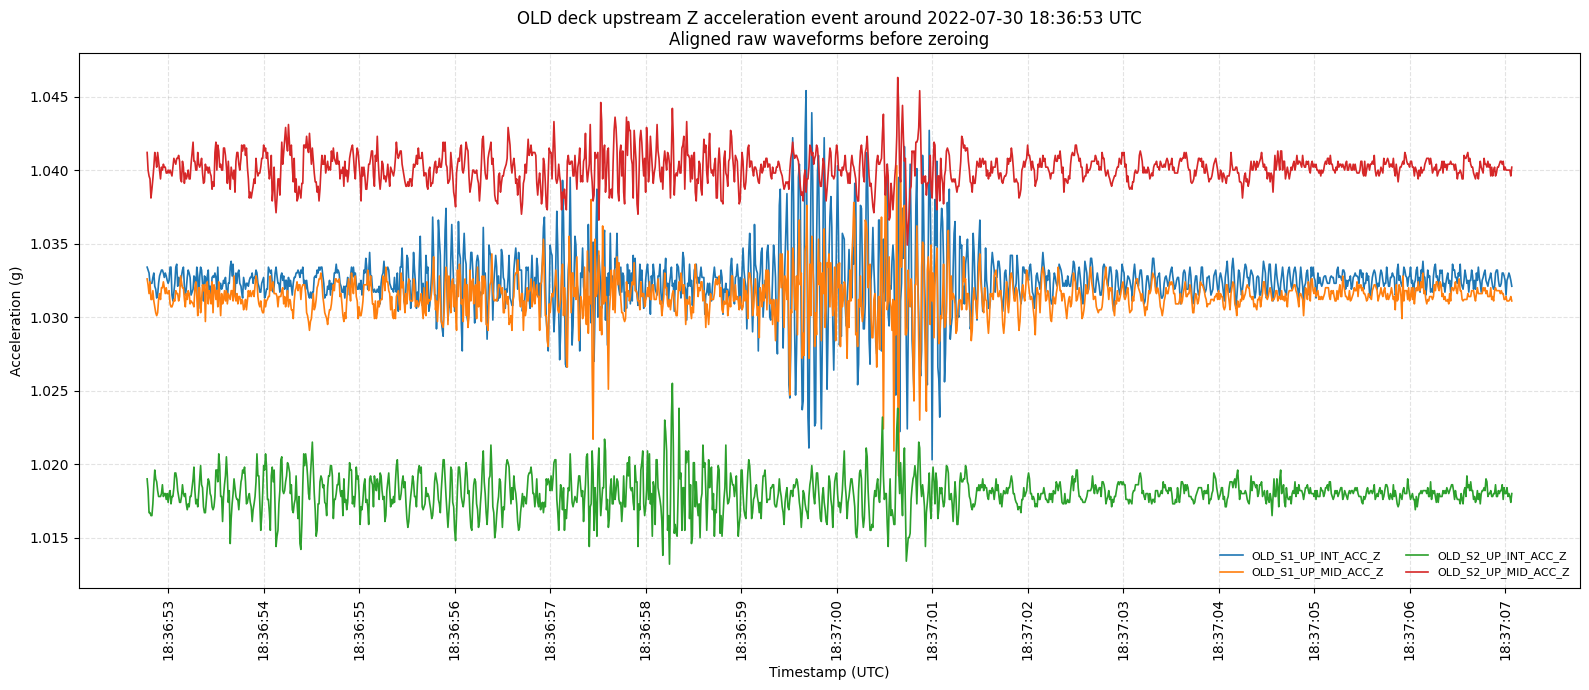

In [7]:
acceleration_timestamp = "2022-07-30 18:36:53"

acceleration_events = find_events(
    reader,
    timestamp=acceleration_timestamp,
    deck="OLD",
    sensor_pattern="*UP*ACC_Z*",
)
if acceleration_events.empty:
    raise ValueError(
        f"No OLD-deck upstream Z acceleration event found for {acceleration_timestamp} in SET1."
    )

acceleration_event = acceleration_events.iloc[0]
acceleration_loaded_event = load_event_group(reader, acceleration_event)
acceleration_aligned_event = align_event_group(acceleration_loaded_event)
acceleration_frame = acceleration_aligned_event.aligned_waveform
acceleration_sensor_columns = [
    column for column in acceleration_frame.columns if column != "timestamp_utc"
]

fig, ax = plt.subplots(figsize=(16, 7))
for sensor_name in acceleration_sensor_columns:
    ax.plot(
        acceleration_frame["timestamp_utc"],
        acceleration_frame[sensor_name],
        linewidth=1.2,
        label=sensor_name,
    )

ax.set_title(
    f"OLD deck upstream Z acceleration event around {acceleration_timestamp} UTC\n"
    "Aligned raw waveforms before zeroing"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Acceleration (g)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()


## See the effect of default zeroing on acceleration

The previous acceleration plot shows the aligned upstream `ACC_Z` event before baseline correction. This cell replots the same event after applying the package default zeroing method.


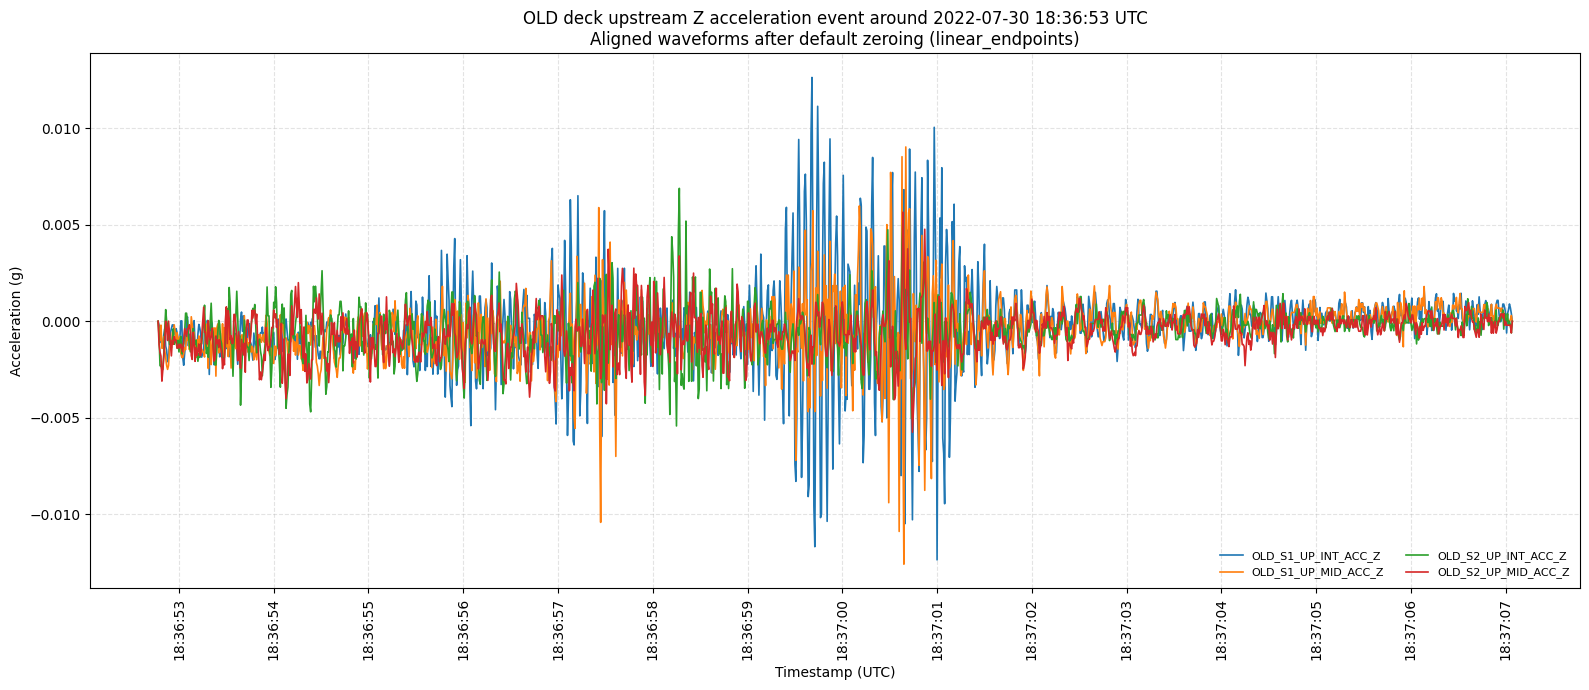

In [8]:
acceleration_zeroed_loaded_event = zero_loaded_event_group(acceleration_loaded_event)
acceleration_zeroed_event = align_event_group(acceleration_zeroed_loaded_event)
acceleration_zeroed_frame = acceleration_zeroed_event.aligned_waveform

fig, ax = plt.subplots(figsize=(16, 7))
for sensor_name in acceleration_sensor_columns:
    ax.plot(
        acceleration_zeroed_frame["timestamp_utc"],
        acceleration_zeroed_frame[sensor_name],
        linewidth=1.2,
        label=sensor_name,
    )

ax.set_title(
    f"OLD deck upstream Z acceleration event around {acceleration_timestamp} UTC\n"
    f"Aligned waveforms after default zeroing ({acceleration_zeroed_event.zeroing_method})"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Acceleration (g)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()


## OLD-deck `ACC_Y` view

This cell shows the `OLD`-deck `ACC_Y` channels after default zeroing. In the released V1.0 dataset, `ACC_Y` channels appear on the downstream side only, so this deck-wide `ACC_Y` view is effectively the available `DO` `ACC_Y` subset for the same event.


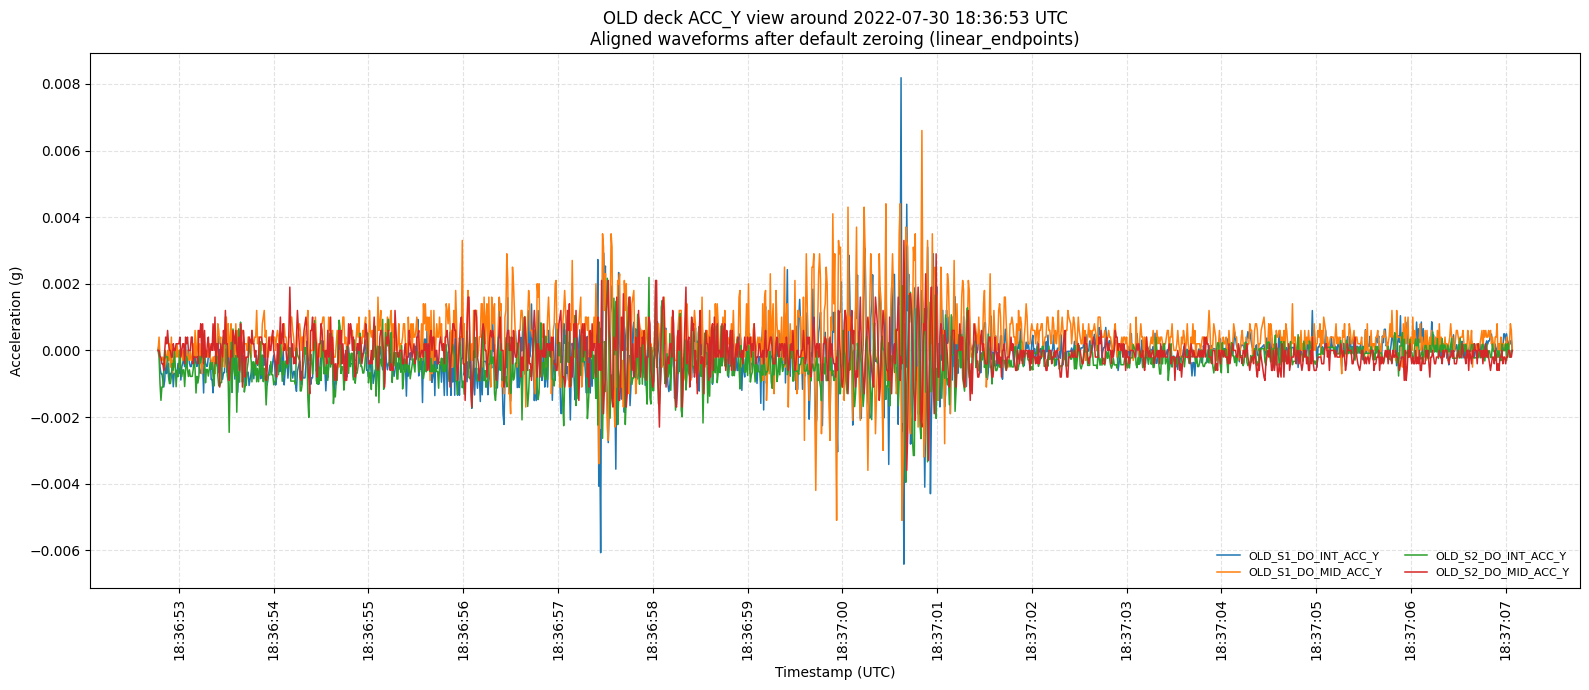

In [9]:
acceleration_y_events = find_events(
    reader,
    timestamp=acceleration_timestamp,
    deck="OLD",
    sensor_pattern="ACC_Y",
)
if acceleration_y_events.empty:
    raise ValueError(
        f"No OLD-deck ACC_Y event found for {acceleration_timestamp} in SET1."
    )

acceleration_y_event = acceleration_y_events.iloc[0]
acceleration_y_loaded_event = load_event_group(reader, acceleration_y_event)
acceleration_y_zeroed_loaded_event = zero_loaded_event_group(acceleration_y_loaded_event)
acceleration_y_zeroed_event = align_event_group(acceleration_y_zeroed_loaded_event)
acceleration_y_frame = acceleration_y_zeroed_event.aligned_waveform
acceleration_y_sensor_columns = [
    column for column in acceleration_y_frame.columns if column != "timestamp_utc"
]

fig, ax = plt.subplots(figsize=(16, 7))
for sensor_name in acceleration_y_sensor_columns:
    ax.plot(
        acceleration_y_frame["timestamp_utc"],
        acceleration_y_frame[sensor_name],
        linewidth=1.1,
        label=sensor_name,
    )

ax.set_title(
    f"OLD deck ACC_Y view around {acceleration_timestamp} UTC\n"
    f"Aligned waveforms after default zeroing ({acceleration_y_zeroed_event.zeroing_method})"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Acceleration (g)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()


## Export a smoke-test artifact

This mirrors the stage behavior on a single event and provides a quick check that the exported aligned tables are numeric and timestamped.


In [10]:
output_path = Path("..") / "results" / "notebook_preprocessing_demo" / f"{organizer_zeroed_event.event_id}.csv"
export_aligned_event(organizer_zeroed_event, output_path)
pd.read_csv(output_path).head()


,timestamp_utc,OLD_S1_DO_SHE_STR,OLD_S1_DO_SUP_STR,OLD_S1_UP_SHE_STR,OLD_S1_UP_SUP_STR,OLD_S2_DO_SHE_STR,OLD_S2_DO_SUP_STR,OLD_S2_UP_INF_STR,OLD_S2_UP_SHE_STR,OLD_S2_UP_SUP_STR
0,2023-04-20T07:04:05.191Z,0.000000,0.000100,0.000000e+00,4.002889e-04,0.000000,0.000300,-1.156069e-07,0.000000e+00,0.000300
1,2023-04-20T07:04:05.199Z,-0.000101,-0.000499,-3.470214e-07,8.665511e-07,0.000499,0.000301,-1.003468e-04,-9.988433e-05,0.000101
2,2023-04-20T07:04:05.209Z,-0.000202,-0.000398,9.930596e-05,-1.988446e-04,-0.000001,0.000401,-2.004624e-04,-2.997687e-04,0.000401
3,2023-04-20T07:04:05.219Z,-0.000102,0.000402,-3.010411e-04,5.014443e-04,-0.000102,0.000801,-3.005780e-04,-7.996530e-04,0.000801
4,2023-04-20T07:04:05.229Z,0.000197,-0.000298,3.986119e-04,5.017331e-04,0.000697,0.001201,-5.006936e-04,4.626952e-07,0.000901
